In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv("ETH_Ward.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ABANTU BATHO CONGRESS,19,11/23/2021 4:11:07 PM
1,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ACADEMIC CONGRESS UNION,0,11/23/2021 4:11:07 PM
2,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ACTIONSA,0,11/23/2021 4:11:07 PM
3,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ACTIVISTS MOVEMENT OF SOUTH AFRICA,0,11/23/2021 4:11:07 PM
4,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ADVANCED DYNAMIC ALLIANCE,0,11/23/2021 4:11:07 PM


In [6]:
df.tail()

,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
32985,KwaZulu-Natal,ETH - eThekwini,Ward 59500111,43583698,MATHOLE COMMUNITY HALL,1962,Ward,29,PEOPLE'S FREEDOM PARTY,0,11/23/2021 4:11:07 PM
32986,KwaZulu-Natal,ETH - eThekwini,Ward 59500111,43583698,MATHOLE COMMUNITY HALL,1962,Ward,29,THE ORGANIC HUMANITY MOVEMENT,0,11/23/2021 4:11:07 PM
32987,KwaZulu-Natal,ETH - eThekwini,Ward 59500111,43583698,MATHOLE COMMUNITY HALL,1962,Ward,29,TRULY ALLIANCE,0,11/23/2021 4:11:07 PM
32988,KwaZulu-Natal,ETH - eThekwini,Ward 59500111,43583698,MATHOLE COMMUNITY HALL,1962,Ward,29,UNITED INDEPENDENT MOVEMENT,0,11/23/2021 4:11:07 PM
32989,KwaZulu-Natal,ETH - eThekwini,Ward 59500111,43583698,MATHOLE COMMUNITY HALL,1962,Ward,29,VRYHEIDSFRONT PLUS,1,11/23/2021 4:11:07 PM


In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 32990
Number of columns: 11


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32990 entries, 0 to 32989
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Province           32990 non-null  str  
 1   Municipality       32990 non-null  str  
 2   Ward               32990 non-null  str  
 3   VotingDistrict     32990 non-null  int64
 4   VotingStationName  32990 non-null  str  
 5   RegisteredVoters   32990 non-null  int64
 6   BallotType         32990 non-null  str  
 7   SpoiltVotes        32990 non-null  int64
 8   PartyName          32990 non-null  str  
 9   TotalValidVotes    32990 non-null  int64
 10  DateGenerated      32990 non-null  str  
dtypes: int64(4), str(7)
memory usage: 1.9 MB


In [9]:
df.isnull().sum()

Province             0
Municipality         0
Ward                 0
VotingDistrict       0
VotingStationName    0
RegisteredVoters     0
BallotType           0
SpoiltVotes          0
PartyName            0
TotalValidVotes      0
DateGenerated        0
dtype: int64

In [10]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [11]:
df.describe()

,VotingDistrict,RegisteredVoters,SpoiltVotes,TotalValidVotes
count,3.299000e+04,32990.000000,32990.000000,32990.000000
mean,4.342043e+07,2185.880115,16.501576,23.522734
std,1.021454e+05,1189.342444,19.547402,111.847546
min,4.335002e+07,107.000000,0.000000,0.000000
25%,4.336170e+07,1363.000000,4.000000,0.000000
50%,4.337166e+07,2057.000000,12.000000,0.000000
75%,4.340056e+07,2823.000000,22.000000,3.000000
max,4.407007e+07,7910.000000,221.000000,3163.000000


In [12]:
print("Number of wards:", df["Ward"].nunique())
print("Number of voting districts:", df["VotingDistrict"].nunique())
print("Number of parties:", df["PartyName"].nunique())

Number of wards: 111
Number of voting districts: 875
Number of parties: 53


In [13]:
df["PartyName"].value_counts()

PartyName
ACADEMIC CONGRESS UNION               875
ACTIVISTS MOVEMENT OF SOUTH AFRICA    875
AFRICA RESTORATION ALLIANCE           875
AFRICAN CHRISTIAN DEMOCRATIC PARTY    875
AFRICAN MANTUNGWA COMMUNITY           875
AFRICAN NATIONAL CONGRESS             875
AFRICAN TRANSFORMATION MOVEMENT       875
AL JAMA-AH                            875
DEMOCRATIC ALLIANCE                   875
DEMOCRATIC LIBERAL CONGRESS           875
ECONOMIC FREEDOM FIGHTERS             875
INKATHA FREEDOM PARTY                 875
JUSTICE AND EMPLOYMENT PARTY          875
KZN INDEPENDENCE                      875
MINORITY FRONT                        875
PEOPLE'S FREEDOM PARTY                875
THE ORGANIC HUMANITY MOVEMENT         875
TRULY ALLIANCE                        875
UNITED INDEPENDENT MOVEMENT           875
VRYHEIDSFRONT PLUS                    875
ALLIED MOVEMENT FOR CHANGE            869
AFRICAN PEOPLE'S MOVEMENT             868
GOOD                                  867
ACTIONSA                

In [14]:
party_votes = (
    df.groupby("PartyName")["TotalValidVotes"]
    .sum()
    .sort_values(ascending=False)
)

party_votes.head(10)

PartyName
AFRICAN NATIONAL CONGRESS             324137
DEMOCRATIC ALLIANCE                   198433
ECONOMIC FREEDOM FIGHTERS              78748
INKATHA FREEDOM PARTY                  51725
INDEPENDENT                            32987
ACTIONSA                               11663
ACTIVE CITIZENS COALITION               8025
AFRICAN CHRISTIAN DEMOCRATIC PARTY      6022
ABANTU BATHO CONGRESS                   5866
AFRICAN TRANSFORMATION MOVEMENT         5131
Name: TotalValidVotes, dtype: int64

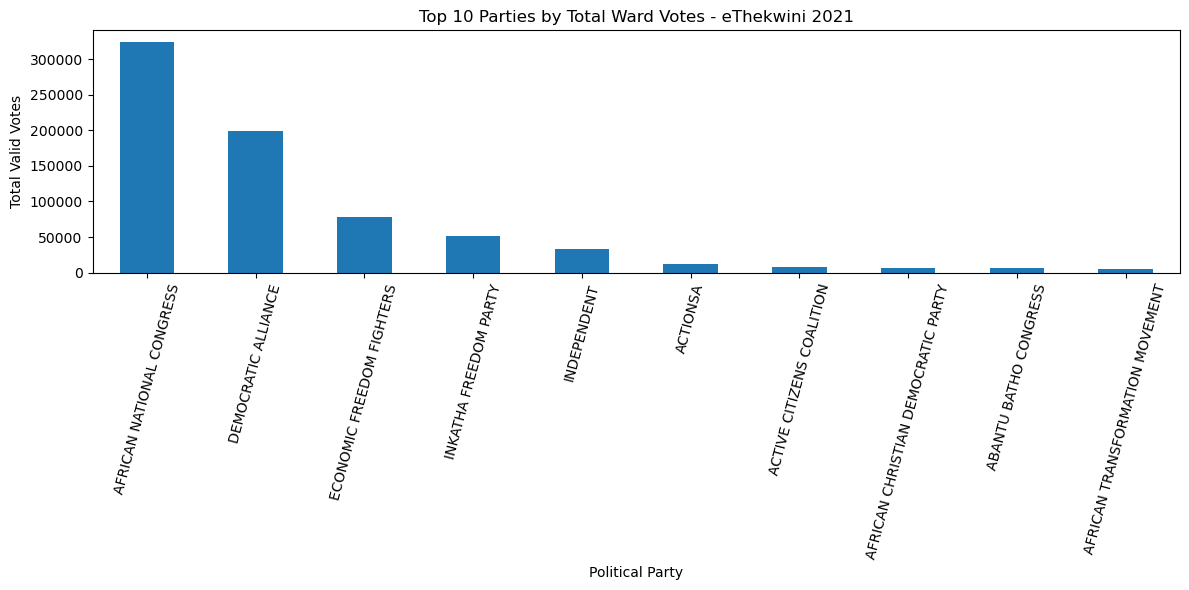

In [15]:
top10 = party_votes.head(10)

plt.figure(figsize=(12, 6))
top10.plot(kind="bar")

plt.title("Top 10 Parties by Total Ward Votes - eThekwini 2021")
plt.xlabel("Political Party")
plt.ylabel("Total Valid Votes")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [16]:
total_votes = party_votes.sum()

party_share = (party_votes / total_votes) * 100

party_share.head(10)

PartyName
AFRICAN NATIONAL CONGRESS             41.769425
DEMOCRATIC ALLIANCE                   25.570769
ECONOMIC FREEDOM FIGHTERS             10.147742
INKATHA FREEDOM PARTY                  6.665464
INDEPENDENT                            4.250820
ACTIONSA                               1.502935
ACTIVE CITIZENS COALITION              1.034129
AFRICAN CHRISTIAN DEMOCRATIC PARTY     0.776016
ABANTU BATHO CONGRESS                  0.755913
AFRICAN TRANSFORMATION MOVEMENT        0.661199
Name: TotalValidVotes, dtype: float64

In [17]:
vd_data = df.drop_duplicates(subset=["VotingDistrict"])

total_registered = vd_data["RegisteredVoters"].sum()

print("Total unique voting districts:", len(vd_data))
print("Total registered voters:", total_registered)

Total unique voting districts: 875
Total registered voters: 1909125


In [18]:
total_valid_votes = df["TotalValidVotes"].sum()

print("Total valid ward votes:", total_valid_votes)

Total valid ward votes: 776015


In [19]:
turnout_rate = (total_valid_votes / total_registered) * 100

print("Estimated 2021 Ward Ballot Turnout:", round(turnout_rate, 2), "%")

Estimated 2021 Ward Ballot Turnout: 40.65 %


In [20]:
ward_party_votes = (
    df.groupby(["Ward", "PartyName"])["TotalValidVotes"]
    .sum()
    .reset_index()
)

ward_party_votes.head()

,Ward,PartyName,TotalValidVotes
0,Ward 59500001,ABANTU BATHO CONGRESS,304
1,Ward 59500001,ACADEMIC CONGRESS UNION,3
2,Ward 59500001,ACTIONSA,16
3,Ward 59500001,ACTIVISTS MOVEMENT OF SOUTH AFRICA,2
4,Ward 59500001,ADVANCED DYNAMIC ALLIANCE,3


In [21]:
ward_winners = ward_party_votes.loc[
    ward_party_votes.groupby("Ward")["TotalValidVotes"].idxmax()
]

ward_winners = ward_winners.sort_values("Ward")

ward_winners.head(20)

,Ward,PartyName,TotalValidVotes
9,Ward 59500001,AFRICAN NATIONAL CONGRESS,9152
46,Ward 59500002,AFRICAN NATIONAL CONGRESS,7057
82,Ward 59500003,AFRICAN NATIONAL CONGRESS,4292
119,Ward 59500004,AFRICAN NATIONAL CONGRESS,6906
157,Ward 59500005,AFRICAN NATIONAL CONGRESS,3623
195,Ward 59500006,AFRICAN NATIONAL CONGRESS,5283
234,Ward 59500007,AFRICAN NATIONAL CONGRESS,3631
271,Ward 59500008,AFRICAN NATIONAL CONGRESS,4699
317,Ward 59500009,DEMOCRATIC ALLIANCE,3560
354,Ward 59500010,DEMOCRATIC ALLIANCE,9105


In [22]:
ward_rankings = ward_party_votes.sort_values(
    ["Ward", "TotalValidVotes"],
    ascending=[True, False]
)

top_two = ward_rankings.groupby("Ward").head(2).copy()

top_two["Rank"] = top_two.groupby("Ward").cumcount() + 1

top_two.head(10)

,Ward,PartyName,TotalValidVotes,Rank
9,Ward 59500001,AFRICAN NATIONAL CONGRESS,9152,1
21,Ward 59500001,ECONOMIC FREEDOM FIGHTERS,495,2
46,Ward 59500002,AFRICAN NATIONAL CONGRESS,7057,1
57,Ward 59500002,ECONOMIC FREEDOM FIGHTERS,895,2
82,Ward 59500003,AFRICAN NATIONAL CONGRESS,4292,1
96,Ward 59500003,INKATHA FREEDOM PARTY,718,2
119,Ward 59500004,AFRICAN NATIONAL CONGRESS,6906,1
130,Ward 59500004,ECONOMIC FREEDOM FIGHTERS,640,2
157,Ward 59500005,AFRICAN NATIONAL CONGRESS,3623,1
168,Ward 59500005,ECONOMIC FREEDOM FIGHTERS,1653,2


In [23]:
ward_comparison = top_two.pivot(
    index="Ward",
    columns="Rank",
    values=["PartyName", "TotalValidVotes"]
)

ward_comparison.columns = [
    "Winner", "RunnerUp", "WinnerVotes", "RunnerUpVotes"
]

ward_comparison["WinningMargin"] = (
    ward_comparison["WinnerVotes"] -
    ward_comparison["RunnerUpVotes"]
)

ward_comparison = ward_comparison.sort_values("WinningMargin")

ward_comparison.head(10)

,Winner,RunnerUp,WinnerVotes,RunnerUpVotes,WinningMargin
Ward,,,,,
Ward 59500026,AFRICAN NATIONAL CONGRESS,DEMOCRATIC ALLIANCE,1237,1221,16
Ward 59500009,DEMOCRATIC ALLIANCE,AFRICAN NATIONAL CONGRESS,3560,3461,99
Ward 59500090,DEMOCRATIC ALLIANCE,AFRICAN NATIONAL CONGRESS,3338,3104,234
Ward 59500028,AFRICAN NATIONAL CONGRESS,ECONOMIC FREEDOM FIGHTERS,1208,972,236
Ward 59500078,AFRICAN NATIONAL CONGRESS,INDEPENDENT,2416,2153,263
Ward 59500061,DEMOCRATIC ALLIANCE,AFRICAN NATIONAL CONGRESS,2204,1853,351
Ward 59500099,AFRICAN NATIONAL CONGRESS,INKATHA FREEDOM PARTY,2417,2059,358
Ward 59500037,AFRICAN NATIONAL CONGRESS,DEMOCRATIC ALLIANCE,2730,2330,400
Ward 59500080,AFRICAN NATIONAL CONGRESS,INDEPENDENT,2150,1721,429


In [24]:
ward_rankings = ward_party_votes.sort_values(
    ["Ward", "TotalValidVotes"],
    ascending=[True, False]
)

top_two = ward_rankings.groupby("Ward").head(2).copy()

top_two["Rank"] = top_two.groupby("Ward").cumcount() + 1

top_two.head(10)

,Ward,PartyName,TotalValidVotes,Rank
9,Ward 59500001,AFRICAN NATIONAL CONGRESS,9152,1
21,Ward 59500001,ECONOMIC FREEDOM FIGHTERS,495,2
46,Ward 59500002,AFRICAN NATIONAL CONGRESS,7057,1
57,Ward 59500002,ECONOMIC FREEDOM FIGHTERS,895,2
82,Ward 59500003,AFRICAN NATIONAL CONGRESS,4292,1
96,Ward 59500003,INKATHA FREEDOM PARTY,718,2
119,Ward 59500004,AFRICAN NATIONAL CONGRESS,6906,1
130,Ward 59500004,ECONOMIC FREEDOM FIGHTERS,640,2
157,Ward 59500005,AFRICAN NATIONAL CONGRESS,3623,1
168,Ward 59500005,ECONOMIC FREEDOM FIGHTERS,1653,2


In [25]:
ward_comparison = top_two.pivot(
    index="Ward",
    columns="Rank",
    values=["PartyName", "TotalValidVotes"]
)

ward_comparison.columns = [
    "Winner", "RunnerUp", "WinnerVotes", "RunnerUpVotes"
]

ward_comparison["WinningMargin"] = (
    ward_comparison["WinnerVotes"] -
    ward_comparison["RunnerUpVotes"]
)

ward_comparison = ward_comparison.sort_values("WinningMargin")

ward_comparison.head(10)

,Winner,RunnerUp,WinnerVotes,RunnerUpVotes,WinningMargin
Ward,,,,,
Ward 59500026,AFRICAN NATIONAL CONGRESS,DEMOCRATIC ALLIANCE,1237,1221,16
Ward 59500009,DEMOCRATIC ALLIANCE,AFRICAN NATIONAL CONGRESS,3560,3461,99
Ward 59500090,DEMOCRATIC ALLIANCE,AFRICAN NATIONAL CONGRESS,3338,3104,234
Ward 59500028,AFRICAN NATIONAL CONGRESS,ECONOMIC FREEDOM FIGHTERS,1208,972,236
Ward 59500078,AFRICAN NATIONAL CONGRESS,INDEPENDENT,2416,2153,263
Ward 59500061,DEMOCRATIC ALLIANCE,AFRICAN NATIONAL CONGRESS,2204,1853,351
Ward 59500099,AFRICAN NATIONAL CONGRESS,INKATHA FREEDOM PARTY,2417,2059,358
Ward 59500037,AFRICAN NATIONAL CONGRESS,DEMOCRATIC ALLIANCE,2730,2330,400
Ward 59500080,AFRICAN NATIONAL CONGRESS,INDEPENDENT,2150,1721,429


## Selection and Justification of Three Wards

Three wards were selected for detailed analysis: Ward 59500026, 
Ward 59500009 and Ward 59500099.

The wards were selected based on the competitiveness of the 2021 historical
election results and to represent different party competition patterns within
eThekwini Municipality.

- **Ward 59500026:** The African National Congress received 1,237 votes,
  while the Democratic Alliance received 1,221 votes. The winning margin was
  only 16 votes, making this a highly competitive ward.

- **Ward 59500009:** The Democratic Alliance received 3,560 votes, while the
  African National Congress received 3,461 votes. The winning margin was
  99 votes, providing a competitive ward in which the DA historically led.

- **Ward 59500099:** The African National Congress received 2,417 votes,
  while the Inkatha Freedom Party received 2,059 votes. The winning margin
  was 358 votes, providing a different competitive pattern involving the IFP.

These wards were therefore selected to provide variation in historical party
competition rather than selecting three wards with similar voting patterns.

The results above represent historical observations from the 2021 Local
Government Election and are not predictions for the 2026 election.

In [26]:
selected_wards = [
    "Ward 59500026",
    "Ward 59500009",
    "Ward 59500099"
]

selected_data = df[df["Ward"].isin(selected_wards)].copy()

print("Selected wards dataset shape:", selected_data.shape)
selected_data.head()

Selected wards dataset shape: (955, 11)


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
3305,KwaZulu-Natal,ETH - eThekwini,Ward 59500009,43400405,KWADINABAKUBO SECONDARY SCHOOL,2676,Ward,30,ABANTU BATHO CONGRESS,2,11/23/2021 4:11:07 PM
3306,KwaZulu-Natal,ETH - eThekwini,Ward 59500009,43400405,KWADINABAKUBO SECONDARY SCHOOL,2676,Ward,30,ACADEMIC CONGRESS UNION,1,11/23/2021 4:11:07 PM
3307,KwaZulu-Natal,ETH - eThekwini,Ward 59500009,43400405,KWADINABAKUBO SECONDARY SCHOOL,2676,Ward,30,ACTIONSA,17,11/23/2021 4:11:07 PM
3308,KwaZulu-Natal,ETH - eThekwini,Ward 59500009,43400405,KWADINABAKUBO SECONDARY SCHOOL,2676,Ward,30,ACTIVE CITIZENS COALITION,0,11/23/2021 4:11:07 PM
3309,KwaZulu-Natal,ETH - eThekwini,Ward 59500009,43400405,KWADINABAKUBO SECONDARY SCHOOL,2676,Ward,30,ACTIVISTS MOVEMENT OF SOUTH AFRICA,1,11/23/2021 4:11:07 PM


In [27]:
selected_results = (
    selected_data.groupby(["Ward", "PartyName"])["TotalValidVotes"]
    .sum()
    .reset_index()
)

selected_results = selected_results.sort_values(
    ["Ward", "TotalValidVotes"],
    ascending=[True, False]
)

selected_results.groupby("Ward").head(5)

,Ward,PartyName,TotalValidVotes
19,Ward 59500009,DEMOCRATIC ALLIANCE,3560
10,Ward 59500009,AFRICAN NATIONAL CONGRESS,3461
24,Ward 59500009,INDEPENDENT,1664
22,Ward 59500009,ECONOMIC FREEDOM FIGHTERS,343
2,Ward 59500009,ACTIONSA,298
50,Ward 59500026,AFRICAN NATIONAL CONGRESS,1237
59,Ward 59500026,DEMOCRATIC ALLIANCE,1221
62,Ward 59500026,ECONOMIC FREEDOM FIGHTERS,468
42,Ward 59500026,ACTIVE CITIZENS COALITION,388
65,Ward 59500026,INKATHA FREEDOM PARTY,171


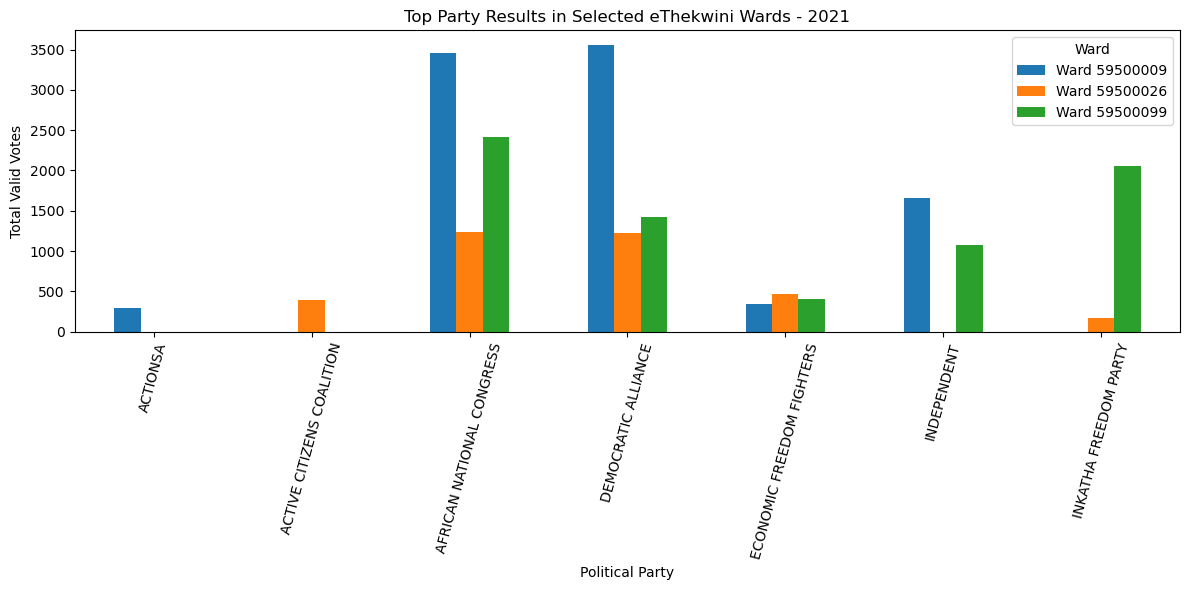

In [28]:
top5_selected = selected_results.groupby("Ward").head(5)

pivot_selected = top5_selected.pivot(
    index="PartyName",
    columns="Ward",
    values="TotalValidVotes"
).fillna(0)

pivot_selected.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Top Party Results in Selected eThekwini Wards - 2021")
plt.xlabel("Political Party")
plt.ylabel("Total Valid Votes")
plt.xticks(rotation=75)
plt.legend(title="Ward")
plt.tight_layout()
plt.show()

In [29]:
df_2016 = pd.read_csv("ETH_Ward (1).csv")

print("2016 dataset loaded successfully!")
print("Rows:", df_2016.shape[0])
print("Columns:", df_2016.shape[1])
print("\nBallot types:")
print(df_2016["BallotType"].value_counts())

2016 dataset loaded successfully!
Rows: 40706
Columns: 11

Ballot types:
BallotType
PR      23382
Ward    17324
Name: count, dtype: int64


In [30]:
df_2016_ward = df_2016[df_2016["BallotType"] == "Ward"].copy()

print("2016 Ward ballot rows:", df_2016_ward.shape[0])
print("2016 wards:", df_2016_ward["Ward"].nunique())
print("2016 voting districts:", df_2016_ward["VotingDistrict"].nunique())

2016 Ward ballot rows: 17324
2016 wards: 110
2016 voting districts: 866


In [31]:
wards_2016 = set(df_2016_ward["Ward"].unique())
wards_2021 = set(df["Ward"].unique())

common_wards = wards_2016.intersection(wards_2021)
only_2016 = wards_2016 - wards_2021
only_2021 = wards_2021 - wards_2016

print("Common ward IDs:", len(common_wards))
print("Only in 2016:", only_2016)
print("Only in 2021:", only_2021)

Common ward IDs: 110
Only in 2016: set()
Only in 2021: {'Ward 59500111'}


## Geographic Comparability of Historical Election Data

The 2016 eThekwini Ward dataset contains 110 wards, while the 2021 dataset
contains 111 wards.

A comparison of ward identifiers found that 110 ward IDs occur in both
datasets, while Ward 59500111 appears only in the 2021 dataset.

Matching ward identifiers do not necessarily prove that the geographic
boundaries remained unchanged between elections. Therefore, historical
ward-level comparisons are treated with caution.

For the selected wards, comparisons will be limited to wards represented in
both datasets, and the possibility of boundary changes is acknowledged as a
limitation of the forecasting analysis.

In [32]:
df_2016_ward["ElectionYear"] = 2016
df["ElectionYear"] = 2021

print("2016 year added:", df_2016_ward["ElectionYear"].unique())
print("2021 year added:", df["ElectionYear"].unique())

2016 year added: [2016]
2021 year added: [2021]


In [33]:
df_2016_common = df_2016_ward[
    df_2016_ward["Ward"].isin(common_wards)
].copy()

df_2021_common = df[
    df["Ward"].isin(common_wards)
].copy()

historical_df = pd.concat(
    [df_2016_common, df_2021_common],
    ignore_index=True
)

print("Combined historical rows:", historical_df.shape[0])
print("Combined columns:", historical_df.shape[1])
print("\nRows by election year:")
print(historical_df["ElectionYear"].value_counts())

Combined historical rows: 50128
Combined columns: 12

Rows by election year:
ElectionYear
2021    32804
2016    17324
Name: count, dtype: int64


In [34]:
parties_by_year = historical_df.groupby("ElectionYear")["PartyName"].nunique()

print("Number of parties by election year:")
print(parties_by_year)

Number of parties by election year:
ElectionYear
2016    28
2021    53
Name: PartyName, dtype: int64


In [35]:
party_year_votes = (
    historical_df
    .groupby(["ElectionYear", "PartyName"])["TotalValidVotes"]
    .sum()
    .reset_index()
)

top_parties = (
    party_year_votes
    .sort_values(
        ["ElectionYear", "TotalValidVotes"],
        ascending=[True, False]
    )
    .groupby("ElectionYear")
    .head(10)
)

top_parties

,ElectionYear,PartyName,TotalValidVotes
4,2016,AFRICAN NATIONAL CONGRESS,593621
10,2016,DEMOCRATIC ALLIANCE,294867
13,2016,INDEPENDENT,93432
16,2016,INKATHA FREEDOM PARTY,46154
12,2016,ECONOMIC FREEDOM FIGHTERS,36552
2,2016,AFRICAN INDEPENDENT CONGRESS,13772
18,2016,MINORITY FRONT,6725
11,2016,DEMOCRATIC LIBERAL CONGRESS,6714
1,2016,AFRICAN CHRISTIAN DEMOCRATIC PARTY,6147
23,2016,TRULY ALLIANCE,4452


In [36]:
major_parties = [
    "AFRICAN NATIONAL CONGRESS",
    "DEMOCRATIC ALLIANCE",
    "ECONOMIC FREEDOM FIGHTERS",
    "INKATHA FREEDOM PARTY"
]

major_party_data = historical_df[
    historical_df["PartyName"].isin(major_parties)
].copy()

major_summary = (
    major_party_data
    .groupby(["ElectionYear", "PartyName"])["TotalValidVotes"]
    .sum()
    .reset_index()
)

major_summary

,ElectionYear,PartyName,TotalValidVotes
0,2016,AFRICAN NATIONAL CONGRESS,593621
1,2016,DEMOCRATIC ALLIANCE,294867
2,2016,ECONOMIC FREEDOM FIGHTERS,36552
3,2016,INKATHA FREEDOM PARTY,46154
4,2021,AFRICAN NATIONAL CONGRESS,319706
5,2021,DEMOCRATIC ALLIANCE,198383
6,2021,ECONOMIC FREEDOM FIGHTERS,78123
7,2021,INKATHA FREEDOM PARTY,51387


In [37]:
party_change = major_summary.pivot(
    index="PartyName",
    columns="ElectionYear",
    values="TotalValidVotes"
)

party_change["VoteChange"] = (
    party_change[2021] - party_change[2016]
)

party_change["PercentChange"] = (
    (party_change[2021] - party_change[2016])
    / party_change[2016] * 100
)

party_change.round(2)

ElectionYear,2016,2021,VoteChange,PercentChange
PartyName,,,,
AFRICAN NATIONAL CONGRESS,593621,319706,-273915,-46.14
DEMOCRATIC ALLIANCE,294867,198383,-96484,-32.72
ECONOMIC FREEDOM FIGHTERS,36552,78123,41571,113.73
INKATHA FREEDOM PARTY,46154,51387,5233,11.34


In [38]:
year_totals = (
    historical_df
    .groupby("ElectionYear")["TotalValidVotes"]
    .sum()
)

major_summary["VoteShare"] = major_summary.apply(
    lambda row: (
        row["TotalValidVotes"] /
        year_totals[row["ElectionYear"]]
    ) * 100,
    axis=1
)

major_summary.round(2)

,ElectionYear,PartyName,TotalValidVotes,VoteShare
0,2016,AFRICAN NATIONAL CONGRESS,593621,52.95
1,2016,DEMOCRATIC ALLIANCE,294867,26.30
2,2016,ECONOMIC FREEDOM FIGHTERS,36552,3.26
3,2016,INKATHA FREEDOM PARTY,46154,4.12
4,2021,AFRICAN NATIONAL CONGRESS,319706,41.50
5,2021,DEMOCRATIC ALLIANCE,198383,25.75
6,2021,ECONOMIC FREEDOM FIGHTERS,78123,10.14
7,2021,INKATHA FREEDOM PARTY,51387,6.67


In [39]:
share_change = major_summary.pivot(
    index="PartyName",
    columns="ElectionYear",
    values="VoteShare"
)

share_change["ShareChange"] = (
    share_change[2021] - share_change[2016]
)

share_change.round(2)

ElectionYear,2016,2021,ShareChange
PartyName,,,
AFRICAN NATIONAL CONGRESS,52.95,41.50,-11.45
DEMOCRATIC ALLIANCE,26.30,25.75,-0.55
ECONOMIC FREEDOM FIGHTERS,3.26,10.14,6.88
INKATHA FREEDOM PARTY,4.12,6.67,2.55


In [40]:
df_2011 = pd.read_csv(
    "ETH_Ward (2).csv",
    encoding="utf-16"
)

print("2011 dataset loaded successfully!")
print("Rows:", df_2011.shape[0])
print("Columns:", df_2011.shape[1])
print("Wards:", df_2011["Ward"].nunique())
print("Voting districts:", df_2011["VotingDistrict"].nunique())
print("Parties:", df_2011["PartyName"].nunique())

print("\nBallot types:")
print(df_2011["BallotType"].value_counts())

2011 dataset loaded successfully!
Rows: 11226
Columns: 11
Wards: 103
Voting districts: 801
Parties: 19

Ballot types:
BallotType
Ward    11226
Name: count, dtype: int64


In [41]:
wards_2011 = set(df_2011["Ward"].unique())
wards_2016 = set(df_2016_ward["Ward"].unique())
wards_2021 = set(df["Ward"].unique())

common_all_years = (
    wards_2011
    .intersection(wards_2016)
    .intersection(wards_2021)
)

print("2011 wards:", len(wards_2011))
print("2016 wards:", len(wards_2016))
print("2021 wards:", len(wards_2021))

print("\nWard IDs appearing in all three elections:",
      len(common_all_years))

print("\nSelected wards:")
for ward in selected_wards:
    print(
        ward,
        "- Present in all years:",
        ward in common_all_years
    )

2011 wards: 103
2016 wards: 110
2021 wards: 111

Ward IDs appearing in all three elections: 103

Selected wards:
Ward 59500026 - Present in all years: True
Ward 59500009 - Present in all years: True
Ward 59500099 - Present in all years: True


In [42]:
for ward in selected_wards:

    vd_2011 = set(
        df_2011[df_2011["Ward"] == ward]["VotingDistrict"].unique()
    )

    vd_2016 = set(
        df_2016_ward[
            df_2016_ward["Ward"] == ward
        ]["VotingDistrict"].unique()
    )

    vd_2021 = set(
        df[df["Ward"] == ward]["VotingDistrict"].unique()
    )

    common_vds = vd_2011 & vd_2016 & vd_2021

    print("\n", ward)
    print("2011 VDs:", len(vd_2011))
    print("2016 VDs:", len(vd_2016))
    print("2021 VDs:", len(vd_2021))
    print("VDs common to all 3 elections:", len(common_vds))


 Ward 59500026
2011 VDs: 5
2016 VDs: 5
2021 VDs: 5
VDs common to all 3 elections: 5

 Ward 59500009
2011 VDs: 8
2016 VDs: 11
2021 VDs: 10
VDs common to all 3 elections: 7

 Ward 59500099
2011 VDs: 12
2016 VDs: 10
2021 VDs: 10
VDs common to all 3 elections: 9


## Geographic Alignment of Selected Wards

Although the three selected ward identifiers appear in the 2011, 2016 and
2021 election datasets, the voting districts contained within the wards were
also examined to assess geographic comparability.

Ward 59500026 contains 5 voting districts in each of the three elections,
and all 5 voting districts are common across 2011, 2016 and 2021. This
provides strong geographic continuity for historical comparison.

Ward 59500009 contains 8 voting districts in 2011, 11 in 2016 and 10 in
2021. Seven voting districts are common across all three elections.

Ward 59500099 contains 12 voting districts in 2011, 10 in 2016 and 10 in
2021. Nine voting districts are common across all three elections.

Because ward boundaries and voting-district assignments may change between
elections, matching ward identifiers alone is not assumed to represent
identical geography. For historical comparisons of the selected wards, the
analysis will therefore focus on voting districts that are common across all
three election years where appropriate.

This alignment strategy reduces, but does not completely eliminate, the
effect of geographic changes between election years.

In [43]:
common_vds_by_ward = {}

for ward in selected_wards:

    vd_2011 = set(
        df_2011[df_2011["Ward"] == ward]["VotingDistrict"].unique()
    )

    vd_2016 = set(
        df_2016_ward[
            df_2016_ward["Ward"] == ward
        ]["VotingDistrict"].unique()
    )

    vd_2021 = set(
        df[df["Ward"] == ward]["VotingDistrict"].unique()
    )

    common_vds_by_ward[ward] = vd_2011 & vd_2016 & vd_2021

for ward, vds in common_vds_by_ward.items():
    print(ward, ":", len(vds), "common VDs")

Ward 59500026 : 5 common VDs
Ward 59500009 : 7 common VDs
Ward 59500099 : 9 common VDs


In [44]:
df_2011["ElectionYear"] = 2011

print("2011 year added:", df_2011["ElectionYear"].unique())

2011 year added: [2011]


In [45]:
df_2011_common = df_2011[
    df_2011["Ward"].isin(common_all_years)
].copy()

df_2016_common = df_2016_ward[
    df_2016_ward["Ward"].isin(common_all_years)
].copy()

df_2021_common = df[
    df["Ward"].isin(common_all_years)
].copy()

historical_df = pd.concat(
    [
        df_2011_common,
        df_2016_common,
        df_2021_common
    ],
    ignore_index=True
)

print("Combined historical rows:", historical_df.shape[0])
print("Combined columns:", historical_df.shape[1])

print("\nRows by election year:")
print(
    historical_df["ElectionYear"]
    .value_counts()
    .sort_index()
)

Combined historical rows: 57591
Combined columns: 12

Rows by election year:
ElectionYear
2011    11226
2016    16089
2021    30276
Name: count, dtype: int64


In [46]:
major_parties = [
    "AFRICAN NATIONAL CONGRESS",
    "DEMOCRATIC ALLIANCE",
    "ECONOMIC FREEDOM FIGHTERS",
    "INKATHA FREEDOM PARTY"
]

year_totals = (
    historical_df
    .groupby("ElectionYear")["TotalValidVotes"]
    .sum()
)

major_trend = (
    historical_df[
        historical_df["PartyName"].isin(major_parties)
    ]
    .groupby(["ElectionYear", "PartyName"])["TotalValidVotes"]
    .sum()
    .reset_index()
)

major_trend["VoteShare"] = major_trend.apply(
    lambda row:
        row["TotalValidVotes"] /
        year_totals[row["ElectionYear"]] * 100,
    axis=1
)

major_trend.round(2)

,ElectionYear,PartyName,TotalValidVotes,VoteShare
0,2011,AFRICAN NATIONAL CONGRESS,582224,60.11
1,2011,INKATHA FREEDOM PARTY,41638,4.30
2,2016,AFRICAN NATIONAL CONGRESS,549578,52.30
3,2016,DEMOCRATIC ALLIANCE,284492,27.08
4,2016,ECONOMIC FREEDOM FIGHTERS,33858,3.22
5,2016,INKATHA FREEDOM PARTY,42519,4.05
6,2021,AFRICAN NATIONAL CONGRESS,297549,41.24
7,2021,DEMOCRATIC ALLIANCE,189480,26.26
8,2021,ECONOMIC FREEDOM FIGHTERS,73218,10.15
9,2021,INKATHA FREEDOM PARTY,47945,6.65


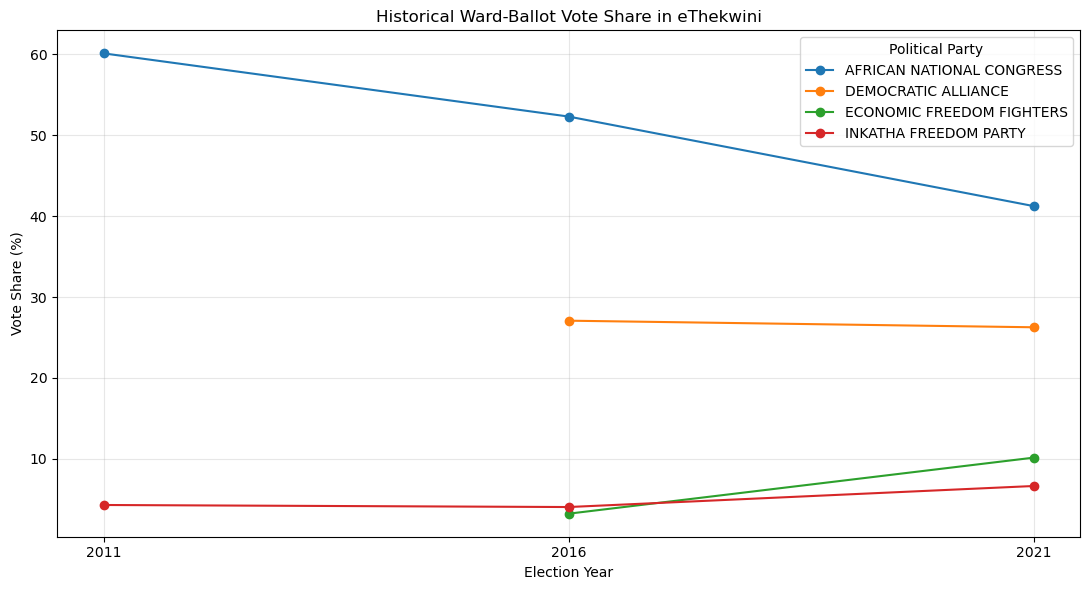

In [47]:
trend_pivot = major_trend.pivot(
    index="ElectionYear",
    columns="PartyName",
    values="VoteShare"
)

trend_pivot.plot(
    marker="o",
    figsize=(11, 6)
)

plt.title("Historical Ward-Ballot Vote Share in eThekwini")
plt.xlabel("Election Year")
plt.ylabel("Vote Share (%)")
plt.xticks([2011, 2016, 2021])
plt.grid(True, alpha=0.3)
plt.legend(title="Political Party")
plt.tight_layout()
plt.show()

In [48]:
print("2011 party names:\n")

for party in sorted(df_2011["PartyName"].unique()):
    print(party)

2011 party names:

AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ALLIANSIE
AFRICAN CHRISTIAN DEMOCRATIC PARTY
AFRICAN NATIONAL CONGRESS
AFRICAN PEOPLE'S CONVENTION
AZANIAN PEOPLE'S ORGANISATION
BLACK CONSCIOUSNESS PARTY
CONGRESS  OF THE PEOPLE
DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE
INDEPENDENT
INKATHA FREEDOM PARTY
MINORITY FRONT
NATIONAL FREEDOM PARTY
SOCIALIST GREEN COALITION
SOLIDARITY PARTY
TRULY ALLIANCE
UNITED ACTION FRONT
UNITED DEMOCRATIC MOVEMENT
UNITED RESIDENTS FRONT
VRYHEIDSFRONT PLUS


In [49]:
df_2011["PartyName"] = df_2011["PartyName"].replace(
    "DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE",
    "DEMOCRATIC ALLIANCE"
)

print(
    df_2011[
        df_2011["PartyName"] == "DEMOCRATIC ALLIANCE"
    ]["PartyName"].value_counts()
)

PartyName
DEMOCRATIC ALLIANCE    611
Name: count, dtype: int64


In [50]:
df_2011_common = df_2011[
    df_2011["Ward"].isin(common_all_years)
].copy()

historical_df = pd.concat(
    [
        df_2011_common,
        df_2016_common,
        df_2021_common
    ],
    ignore_index=True
)

print("Historical dataset rebuilt successfully.")
print("Total rows:", len(historical_df))

Historical dataset rebuilt successfully.
Total rows: 57591


In [51]:
year_totals = (
    historical_df
    .groupby("ElectionYear")["TotalValidVotes"]
    .sum()
)

major_trend = (
    historical_df[
        historical_df["PartyName"].isin(major_parties)
    ]
    .groupby(["ElectionYear", "PartyName"])["TotalValidVotes"]
    .sum()
    .reset_index()
)

major_trend["VoteShare"] = major_trend.apply(
    lambda row:
        row["TotalValidVotes"] /
        year_totals[row["ElectionYear"]] * 100,
    axis=1
)

major_trend.round(2)


,ElectionYear,PartyName,TotalValidVotes,VoteShare
0,2011,AFRICAN NATIONAL CONGRESS,582224,60.11
1,2011,DEMOCRATIC ALLIANCE,195770,20.21
2,2011,INKATHA FREEDOM PARTY,41638,4.30
3,2016,AFRICAN NATIONAL CONGRESS,549578,52.30
4,2016,DEMOCRATIC ALLIANCE,284492,27.08
5,2016,ECONOMIC FREEDOM FIGHTERS,33858,3.22
6,2016,INKATHA FREEDOM PARTY,42519,4.05
7,2021,AFRICAN NATIONAL CONGRESS,297549,41.24
8,2021,DEMOCRATIC ALLIANCE,189480,26.26
9,2021,ECONOMIC FREEDOM FIGHTERS,73218,10.15


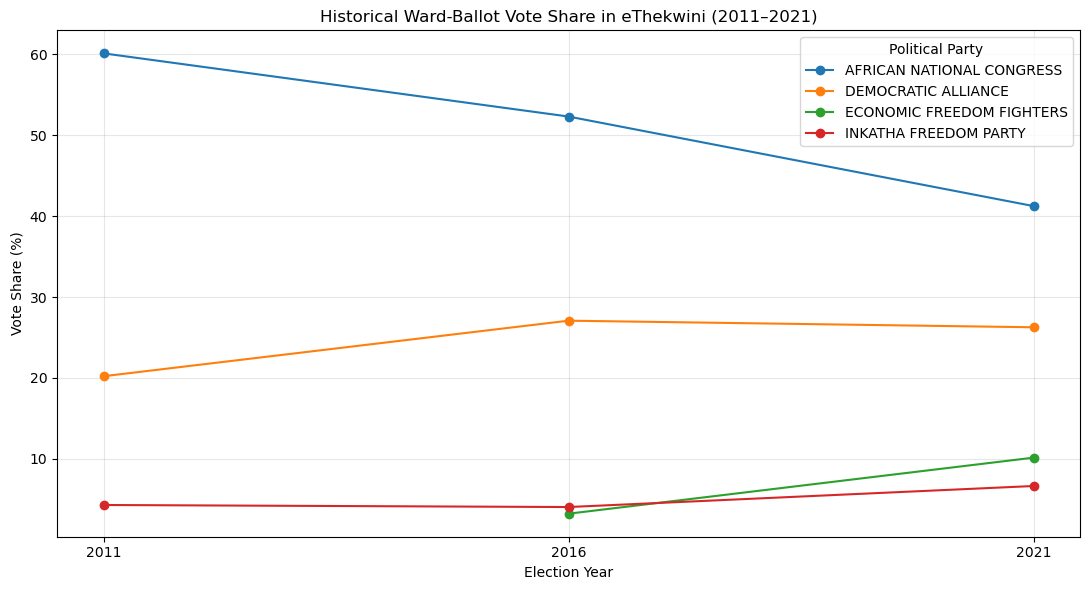

In [52]:
trend_pivot = major_trend.pivot(
    index="ElectionYear",
    columns="PartyName",
    values="VoteShare"
)

trend_pivot.plot(
    marker="o",
    figsize=(11, 6)
)

plt.title("Historical Ward-Ballot Vote Share in eThekwini (2011–2021)")
plt.xlabel("Election Year")
plt.ylabel("Vote Share (%)")
plt.xticks([2011, 2016, 2021])
plt.grid(True, alpha=0.3)
plt.legend(title="Political Party")
plt.tight_layout()
plt.show()

In [53]:
model_data = (
    historical_df[
        historical_df["PartyName"].isin(major_parties)
    ]
    .groupby(
        [
            "ElectionYear",
            "Ward",
            "VotingDistrict",
            "PartyName"
        ],
        as_index=False
    )
    .agg(
        RegisteredVoters=("RegisteredVoters", "first"),
        PartyVotes=("TotalValidVotes", "sum")
    )
)

print("Model dataset rows:", model_data.shape[0])
print("Model dataset columns:", model_data.shape[1])

model_data.head(10)

Model dataset rows: 8531
Model dataset columns: 6


,ElectionYear,Ward,VotingDistrict,PartyName,RegisteredVoters,PartyVotes
0,2011,Ward 59500001,43400179,AFRICAN NATIONAL CONGRESS,1438,942
1,2011,Ward 59500001,43400179,DEMOCRATIC ALLIANCE,1438,7
2,2011,Ward 59500001,43400179,INKATHA FREEDOM PARTY,1438,3
3,2011,Ward 59500001,43400180,AFRICAN NATIONAL CONGRESS,1464,5
4,2011,Ward 59500001,43400180,DEMOCRATIC ALLIANCE,1464,0
5,2011,Ward 59500001,43400180,INKATHA FREEDOM PARTY,1464,0
6,2011,Ward 59500001,43400191,AFRICAN NATIONAL CONGRESS,787,129
7,2011,Ward 59500001,43400191,DEMOCRATIC ALLIANCE,787,185
8,2011,Ward 59500001,43400191,INKATHA FREEDOM PARTY,787,10
9,2011,Ward 59500001,43400528,AFRICAN NATIONAL CONGRESS,2282,1770


In [54]:
print("Rows by election year:")
print(
    model_data["ElectionYear"]
    .value_counts()
    .sort_index()
)

print("\nTotal model observations:", len(model_data))

Rows by election year:
ElectionYear
2011    2201
2016    3130
2021    3200
Name: count, dtype: int64

Total model observations: 8531


In [55]:
vd_totals = (
    historical_df
    .groupby(
        ["ElectionYear", "VotingDistrict"]
    )["TotalValidVotes"]
    .sum()
    .reset_index(name="VDTotalValidVotes")
)

model_data = model_data.merge(
    vd_totals,
    on=["ElectionYear", "VotingDistrict"],
    how="left"
)

model_data["PartyVoteShare"] = (
    model_data["PartyVotes"] /
    model_data["VDTotalValidVotes"]
) * 100

model_data.head(10)

,ElectionYear,Ward,VotingDistrict,PartyName,RegisteredVoters,PartyVotes,VDTotalValidVotes,PartyVoteShare
0,2011,Ward 59500001,43400179,AFRICAN NATIONAL CONGRESS,1438,942,964,97.717842
1,2011,Ward 59500001,43400179,DEMOCRATIC ALLIANCE,1438,7,964,0.726141
2,2011,Ward 59500001,43400179,INKATHA FREEDOM PARTY,1438,3,964,0.311203
3,2011,Ward 59500001,43400180,AFRICAN NATIONAL CONGRESS,1464,5,5,100.000000
4,2011,Ward 59500001,43400180,DEMOCRATIC ALLIANCE,1464,0,5,0.000000
5,2011,Ward 59500001,43400180,INKATHA FREEDOM PARTY,1464,0,5,0.000000
6,2011,Ward 59500001,43400191,AFRICAN NATIONAL CONGRESS,787,129,338,38.165680
7,2011,Ward 59500001,43400191,DEMOCRATIC ALLIANCE,787,185,338,54.733728
8,2011,Ward 59500001,43400191,INKATHA FREEDOM PARTY,787,10,338,2.958580
9,2011,Ward 59500001,43400528,AFRICAN NATIONAL CONGRESS,2282,1770,1779,99.494098


In [56]:
print(model_data["PartyVoteShare"].describe())

print(
    "\nMissing vote shares:",
    model_data["PartyVoteShare"].isnull().sum()
)

count    8531.000000
mean       23.851327
std        30.261933
min         0.000000
25%         1.851852
50%         6.228956
75%        44.231263
max       100.000000
Name: PartyVoteShare, dtype: float64

Missing vote shares: 0


In [57]:
model_data = model_data.sort_values(
    ["VotingDistrict", "PartyName", "ElectionYear"]
).copy()

model_data.head()


,ElectionYear,Ward,VotingDistrict,PartyName,RegisteredVoters,PartyVotes,VDTotalValidVotes,PartyVoteShare
771,2011,Ward 59500035,43350016,AFRICAN NATIONAL CONGRESS,3724,199,2242,8.876004
772,2011,Ward 59500035,43350016,DEMOCRATIC ALLIANCE,3724,1969,2242,87.823372
773,2011,Ward 59500035,43350016,INKATHA FREEDOM PARTY,3724,4,2242,0.178412
774,2011,Ward 59500035,43350027,AFRICAN NATIONAL CONGRESS,3519,202,2316,8.721934
3239,2016,Ward 59500035,43350027,AFRICAN NATIONAL CONGRESS,2953,156,1952,7.991803


In [58]:
model_data["PreviousVoteShare"] = (
    model_data
    .groupby(["VotingDistrict", "PartyName"])["PartyVoteShare"]
    .shift(1)
)

model_data["PreviousPartyVotes"] = (
    model_data
    .groupby(["VotingDistrict", "PartyName"])["PartyVotes"]
    .shift(1)
)

model_data["PreviousRegisteredVoters"] = (
    model_data
    .groupby(["VotingDistrict", "PartyName"])["RegisteredVoters"]
    .shift(1)
)

model_data[
    [
        "ElectionYear",
        "VotingDistrict",
        "PartyName",
        "PartyVoteShare",
        "PreviousVoteShare"
    ]
].head(15)

,ElectionYear,VotingDistrict,PartyName,PartyVoteShare,PreviousVoteShare
771,2011,43350016,AFRICAN NATIONAL CONGRESS,8.876004,NaN
772,2011,43350016,DEMOCRATIC ALLIANCE,87.823372,NaN
773,2011,43350016,INKATHA FREEDOM PARTY,0.178412,NaN
774,2011,43350027,AFRICAN NATIONAL CONGRESS,8.721934,NaN
3239,2016,43350027,AFRICAN NATIONAL CONGRESS,7.991803,8.721934
6411,2021,43350027,AFRICAN NATIONAL CONGRESS,4.030710,7.991803
775,2011,43350027,DEMOCRATIC ALLIANCE,88.471503,NaN
3240,2016,43350027,DEMOCRATIC ALLIANCE,88.831967,88.471503
6412,2021,43350027,DEMOCRATIC ALLIANCE,87.523992,88.831967
3241,2016,43350027,ECONOMIC FREEDOM FIGHTERS,0.870902,NaN


In [62]:
ml_data = model_data.dropna(
    subset=["PreviousVoteShare"]
).copy()

print("Original observations:", len(model_data))
print("Observations with previous-election history:", len(ml_data))

print("\nUsable observations by target election:")
print(
    ml_data["ElectionYear"]
    .value_counts()
    .sort_index()
)

Original observations: 8531
Observations with previous-election history: 5175

Usable observations by target election:
ElectionYear
2016    2045
2021    3130
Name: count, dtype: int64


In [63]:
train_data = ml_data[
    ml_data["ElectionYear"] == 2016
].copy()

test_data = ml_data[
    ml_data["ElectionYear"] == 2021
].copy()

print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))

print("\nTraining target year:")
print(train_data["ElectionYear"].unique())

print("\nTesting target year:")
print(test_data["ElectionYear"].unique())

Training observations: 2045
Testing observations: 3130

Training target year:
[2016]

Testing target year:
[2021]


In [64]:
features = [
    "PreviousVoteShare",
    "PreviousPartyVotes",
    "PreviousRegisteredVoters"
]

target = "PartyVoteShare"

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2045, 3)
X_test shape: (3130, 3)
y_train shape: (2045,)
y_test shape: (3130,)


In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [66]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("LINEAR REGRESSION RESULTS")
print("MAE:", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²:", round(linear_r2, 4))

LINEAR REGRESSION RESULTS
MAE: 7.27
RMSE: 10.99
R²: 0.8165


In [68]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Decision Tree
dt_model = DecisionTreeRegressor(
    random_state=42
)

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)

# Train models
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")
print("Random Forest trained successfully!")
print("Gradient Boosting trained successfully!")

Decision Tree trained successfully!
Random Forest trained successfully!
Gradient Boosting trained successfully!


In [69]:
# Make predictions
dt_predictions = dt_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)
gb_predictions = gb_model.predict(X_test)

# Store model results
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        mean_absolute_error(y_test, linear_predictions),
        mean_absolute_error(y_test, dt_predictions),
        mean_absolute_error(y_test, rf_predictions),
        mean_absolute_error(y_test, gb_predictions)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_predictions)),
        np.sqrt(mean_squared_error(y_test, dt_predictions)),
        np.sqrt(mean_squared_error(y_test, rf_predictions)),
        np.sqrt(mean_squared_error(y_test, gb_predictions))
    ],

    "R2": [
        r2_score(y_test, linear_predictions),
        r2_score(y_test, dt_predictions),
        r2_score(y_test, rf_predictions),
        r2_score(y_test, gb_predictions)
    ]
})

model_results = model_results.sort_values(
    "R2",
    ascending=False
)

model_results.round(4)

,Model,MAE,RMSE,R2
0,Linear Regression,7.2654,10.9943,0.8165
3,Gradient Boosting,7.8652,12.1807,0.7747
2,Random Forest,8.0151,12.5402,0.7612
1,Decision Tree,9.6572,15.3419,0.6427


## Model Evaluation and Selection

Four regression models were evaluated using a time-based validation strategy.
The models were trained using historical observations targeting the 2016
election and evaluated on the unseen 2021 election.

The Linear Regression model produced the best overall performance:

- Linear Regression: R² = 0.8165, MAE = 7.27, RMSE = 10.99
- Gradient Boosting: R² = 0.7747, MAE = 7.87, RMSE = 12.18
- Random Forest: R² = 0.7612, MAE = 8.02, RMSE = 12.54
- Decision Tree: R² = 0.6427, MAE = 9.66, RMSE = 15.34

Linear Regression was selected because it achieved the highest R² and the
lowest MAE and RMSE on the unseen 2021 election data.

An R² of 0.8165 indicates that the model explained approximately 81.65% of
the variation in party vote share in the test data. R² is a regression
evaluation metric and should not be interpreted as classification accuracy.

The use of a time-based validation strategy is appropriate for election
forecasting because future election observations were not included in the
training data.

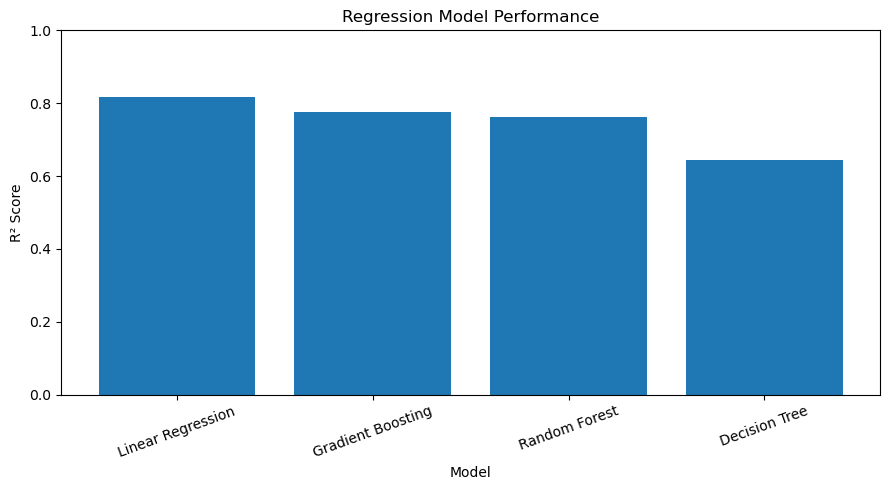

In [70]:
model_results_plot = model_results.sort_values(
    "R2",
    ascending=False
)

plt.figure(figsize=(9, 5))

plt.bar(
    model_results_plot["Model"],
    model_results_plot["R2"]
)

plt.title("Regression Model Performance")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [71]:
X_all = ml_data[features]
y_all = ml_data[target]

final_model = LinearRegression()

final_model.fit(X_all, y_all)

print("Final Linear Regression model trained successfully!")
print("Training observations:", len(X_all))
print("Features used:", features)

Final Linear Regression model trained successfully!
Training observations: 5175
Features used: ['PreviousVoteShare', 'PreviousPartyVotes', 'PreviousRegisteredVoters']


In [72]:
prediction_2026 = model_data[
    model_data["ElectionYear"] == 2021
].copy()

prediction_2026["PreviousVoteShare"] = (
    prediction_2026["PartyVoteShare"]
)

prediction_2026["PreviousPartyVotes"] = (
    prediction_2026["PartyVotes"]
)

prediction_2026["PreviousRegisteredVoters"] = (
    prediction_2026["RegisteredVoters"]
)

print("2026 prediction observations:", len(prediction_2026))

prediction_2026[
    [
        "Ward",
        "VotingDistrict",
        "PartyName",
        "PreviousVoteShare",
        "PreviousPartyVotes",
        "PreviousRegisteredVoters"
    ]
].head(10)

2026 prediction observations: 3200


,Ward,VotingDistrict,PartyName,PreviousVoteShare,PreviousPartyVotes,PreviousRegisteredVoters
6411,Ward 59500035,43350027,AFRICAN NATIONAL CONGRESS,4.030710,63,2796
6412,Ward 59500035,43350027,DEMOCRATIC ALLIANCE,87.523992,1368,2796
6413,Ward 59500035,43350027,ECONOMIC FREEDOM FIGHTERS,0.767754,12,2796
6414,Ward 59500035,43350027,INKATHA FREEDOM PARTY,0.959693,15,2796
6415,Ward 59500035,43350038,AFRICAN NATIONAL CONGRESS,4.470273,100,4522
6416,Ward 59500035,43350038,DEMOCRATIC ALLIANCE,86.589182,1937,4522
6417,Ward 59500035,43350038,ECONOMIC FREEDOM FIGHTERS,0.044703,1,4522
6418,Ward 59500035,43350038,INKATHA FREEDOM PARTY,1.162271,26,4522
8463,Ward 59500102,43350049,AFRICAN NATIONAL CONGRESS,2.117336,48,3731
8464,Ward 59500102,43350049,DEMOCRATIC ALLIANCE,86.369652,1958,3731


In [73]:
X_2026 = prediction_2026[features]

prediction_2026["PredictedVoteShare2026"] = (
    final_model.predict(X_2026)
)

print("2026 predictions generated successfully!")

print(
    prediction_2026["PredictedVoteShare2026"]
    .describe()
)

print(
    "\nPredictions below 0%:",
    (prediction_2026["PredictedVoteShare2026"] < 0).sum()
)

print(
    "Predictions above 100%:",
    (prediction_2026["PredictedVoteShare2026"] > 100).sum()
)

2026 predictions generated successfully!
count    3200.000000
mean       21.192130
std        21.042009
min         3.861495
25%         5.680979
50%        10.448097
75%        31.858541
max        84.094122
Name: PredictedVoteShare2026, dtype: float64

Predictions below 0%: 0
Predictions above 100%: 0


In [74]:
selected_2026 = prediction_2026[
    prediction_2026["Ward"].isin(selected_wards)
].copy()

ward_2026_predictions = (
    selected_2026
    .groupby(["Ward", "PartyName"])
    .apply(
        lambda x: np.average(
            x["PredictedVoteShare2026"],
            weights=x["VDTotalValidVotes"]
        )
    )
    .reset_index(name="PredictedVoteShare2026")
)

ward_2026_predictions = ward_2026_predictions.sort_values(
    ["Ward", "PredictedVoteShare2026"],
    ascending=[True, False]
)

ward_2026_predictions.round(2)

,Ward,PartyName,PredictedVoteShare2026
1,Ward 59500009,DEMOCRATIC ALLIANCE,33.50
0,Ward 59500009,AFRICAN NATIONAL CONGRESS,32.19
2,Ward 59500009,ECONOMIC FREEDOM FIGHTERS,6.75
3,Ward 59500009,INKATHA FREEDOM PARTY,5.34
4,Ward 59500026,AFRICAN NATIONAL CONGRESS,30.28
5,Ward 59500026,DEMOCRATIC ALLIANCE,29.96
6,Ward 59500026,ECONOMIC FREEDOM FIGHTERS,13.90
7,Ward 59500026,INKATHA FREEDOM PARTY,7.58
8,Ward 59500099,AFRICAN NATIONAL CONGRESS,29.34
11,Ward 59500099,INKATHA FREEDOM PARTY,25.64


In [75]:
ward_ranked_2026 = ward_2026_predictions.sort_values(
    ["Ward", "PredictedVoteShare2026"],
    ascending=[True, False]
)

top_two_2026 = (
    ward_ranked_2026
    .groupby("Ward")
    .head(2)
    .copy()
)

top_two_2026["Rank"] = (
    top_two_2026
    .groupby("Ward")
    .cumcount() + 1
)

ward_leaders_2026 = top_two_2026.pivot(
    index="Ward",
    columns="Rank",
    values=["PartyName", "PredictedVoteShare2026"]
)

ward_leaders_2026.columns = [
    "ProjectedLeader",
    "ProjectedRunnerUp",
    "LeaderShare",
    "RunnerUpShare"
]

ward_leaders_2026["ProjectedMargin"] = (
    ward_leaders_2026["LeaderShare"] -
    ward_leaders_2026["RunnerUpShare"]
)

ward_leaders_2026.round(2)

,ProjectedLeader,ProjectedRunnerUp,LeaderShare,RunnerUpShare,ProjectedMargin
Ward,,,,,
Ward 59500009,DEMOCRATIC ALLIANCE,AFRICAN NATIONAL CONGRESS,33.498114,32.187293,1.310821
Ward 59500026,AFRICAN NATIONAL CONGRESS,DEMOCRATIC ALLIANCE,30.282201,29.962201,0.32
Ward 59500099,AFRICAN NATIONAL CONGRESS,INKATHA FREEDOM PARTY,29.339211,25.639395,3.699816


In [76]:
metro_2026 = (
    prediction_2026
    .groupby("PartyName")
    .apply(
        lambda x: np.average(
            x["PredictedVoteShare2026"],
            weights=x["VDTotalValidVotes"]
        )
    )
    .reset_index(name="PredictedVoteShare2026")
)

metro_2026 = metro_2026.sort_values(
    "PredictedVoteShare2026",
    ascending=False
)

metro_2026.round(2)

,PartyName,PredictedVoteShare2026
0,AFRICAN NATIONAL CONGRESS,37.75
1,DEMOCRATIC ALLIANCE,25.51
2,ECONOMIC FREEDOM FIGHTERS,12.25
3,INKATHA FREEDOM PARTY,9.38


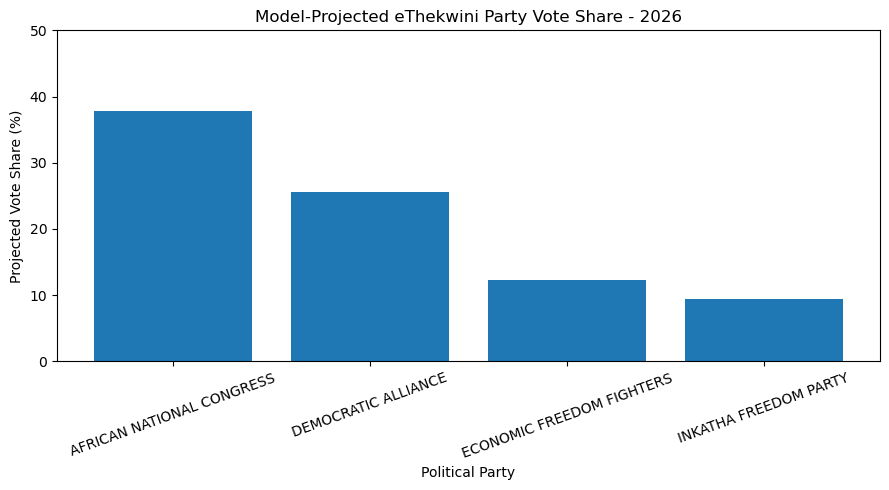

In [77]:
plt.figure(figsize=(9, 5))

plt.bar(
    metro_2026["PartyName"],
    metro_2026["PredictedVoteShare2026"]
)

plt.title("Model-Projected eThekwini Party Vote Share - 2026")
plt.xlabel("Political Party")
plt.ylabel("Projected Vote Share (%)")
plt.xticks(rotation=20)
plt.ylim(0, 50)
plt.tight_layout()
plt.show()

## 2026 eThekwini Party Projection

The selected Linear Regression model projects the African National Congress
as having the largest Ward-ballot vote share among the four modelled parties
in eThekwini in 2026.

The projected shares are:

- African National Congress: 37.75%
- Democratic Alliance: 25.51%
- Economic Freedom Fighters: 12.25%
- Inkatha Freedom Party: 9.38%

These values are model-generated predictions and are not historical
observations or official election results.

The four projected percentages are not normalised to 100%, because parties
and independent candidates outside the four modelled parties are not included
in this model.

The ANC projection is below 50%. However, this result alone is not sufficient
to determine whether a governing coalition will be required. Municipal
governance depends on council seat allocation and other electoral outcomes,
including proportional-representation results. Therefore, the model output is
reported without interpreting it as a prediction of which party or coalition
will govern eThekwini.

The predictions are subject to uncertainty. The selected model achieved an
R² of 0.8165, MAE of 7.27 percentage points and RMSE of 10.99 percentage
points when evaluated on the unseen 2021 election.

In [78]:
turnout_data = (
    historical_df
    .groupby(
        ["ElectionYear", "Ward", "VotingDistrict"],
        as_index=False
    )
    .agg(
        RegisteredVoters=("RegisteredVoters", "first"),
        ValidVotes=("TotalValidVotes", "sum"),
        SpoiltVotes=("SpoiltVotes", "first")
    )
)

# Estimated ballots cast
turnout_data["EstimatedBallotsCast"] = (
    turnout_data["ValidVotes"] +
    turnout_data["SpoiltVotes"]
)

# Estimated turnout percentage
turnout_data["TurnoutRate"] = (
    turnout_data["EstimatedBallotsCast"] /
    turnout_data["RegisteredVoters"]
) * 100

print("Turnout observations:", len(turnout_data))

print("\nObservations by election year:")
print(
    turnout_data["ElectionYear"]
    .value_counts()
    .sort_index()
)

print("\nTurnout rate summary:")
print(
    turnout_data["TurnoutRate"]
    .describe()
)

print("\nImpossible turnout rates:")
print(
    "Below 0%:",
    (turnout_data["TurnoutRate"] < 0).sum()
)

print(
    "Above 100%:",
    (turnout_data["TurnoutRate"] > 100).sum()
)

Turnout observations: 2397

Observations by election year:
ElectionYear
2011    801
2016    796
2021    800
Name: count, dtype: int64

Turnout rate summary:
count    2397.000000
mean       54.924911
std        12.621846
min         0.149254
25%        46.903995
50%        56.538763
75%        63.607085
max       128.659666
Name: TurnoutRate, dtype: float64

Impossible turnout rates:
Below 0%: 0
Above 100%: 2


In [79]:
invalid_turnout = turnout_data[
    turnout_data["TurnoutRate"] > 100
].copy()

invalid_turnout[
    [
        "ElectionYear",
        "Ward",
        "VotingDistrict",
        "RegisteredVoters",
        "ValidVotes",
        "SpoiltVotes",
        "EstimatedBallotsCast",
        "TurnoutRate"
    ]
].round(2)

,ElectionYear,Ward,VotingDistrict,RegisteredVoters,ValidVotes,SpoiltVotes,EstimatedBallotsCast,TurnoutRate
1325,2016,Ward 59500069,43371592,1619,2083,0,2083,128.66
1627,2021,Ward 59500002,43584767,252,249,7,256,101.59


In [80]:
turnout_clean = turnout_data[
    (turnout_data["TurnoutRate"] >= 0) &
    (turnout_data["TurnoutRate"] <= 100)
].copy()

print("Original observations:", len(turnout_data))
print("Removed impossible observations:",
      len(turnout_data) - len(turnout_clean))
print("Remaining observations:", len(turnout_clean))

print("\nObservations by year:")
print(
    turnout_clean["ElectionYear"]
    .value_counts()
    .sort_index()
)

print("\nClean turnout summary:")
print(
    turnout_clean["TurnoutRate"]
    .describe()
)

Original observations: 2397
Removed impossible observations: 2
Remaining observations: 2395

Observations by year:
ElectionYear
2011    801
2016    795
2021    799
Name: count, dtype: int64

Clean turnout summary:
count    2395.000000
mean       54.874641
std        12.500441
min         0.149254
25%        46.890436
50%        56.538763
75%        63.595329
max        93.831554
Name: TurnoutRate, dtype: float64


In [81]:
# Create a copy containing the previous election's values
previous_turnout = turnout_clean[
    [
        "ElectionYear",
        "VotingDistrict",
        "TurnoutRate",
        "RegisteredVoters",
        "EstimatedBallotsCast"
    ]
].copy()

# Move each observation forward by 5 years
previous_turnout["ElectionYear"] = (
    previous_turnout["ElectionYear"] + 5
)

# Rename as previous-election features
previous_turnout = previous_turnout.rename(
    columns={
        "TurnoutRate": "PreviousTurnoutRate",
        "RegisteredVoters": "PreviousRegisteredVoters",
        "EstimatedBallotsCast": "PreviousBallotsCast"
    }
)

# Match each election with exactly the election 5 years earlier
turnout_ml = turnout_clean.merge(
    previous_turnout,
    on=["ElectionYear", "VotingDistrict"],
    how="left"
)

# Keep observations that have an exact previous-election match
turnout_ml = turnout_ml.dropna(
    subset=["PreviousTurnoutRate"]
).copy()

print("Usable turnout ML observations:", len(turnout_ml))

print("\nTarget observations by year:")
print(
    turnout_ml["ElectionYear"]
    .value_counts()
    .sort_index()
)

turnout_ml[
    [
        "ElectionYear",
        "Ward",
        "VotingDistrict",
        "TurnoutRate",
        "PreviousTurnoutRate",
        "PreviousRegisteredVoters",
        "PreviousBallotsCast"
    ]
].head(10)

Usable turnout ML observations: 1538

Target observations by year:
ElectionYear
2016    759
2021    779
Name: count, dtype: int64


,ElectionYear,Ward,VotingDistrict,TurnoutRate,PreviousTurnoutRate,PreviousRegisteredVoters,PreviousBallotsCast
801,2016,Ward 59500001,43400179,76.789048,70.792768,1438.0,1018.0
802,2016,Ward 59500001,43400180,69.210174,0.341530,1464.0,5.0
803,2016,Ward 59500001,43400191,68.839779,43.456163,787.0,342.0
804,2016,Ward 59500001,43400528,70.294906,79.316389,2282.0,1810.0
805,2016,Ward 59500001,43400539,75.668948,77.463863,1522.0,1179.0
806,2016,Ward 59500001,43400595,79.131653,70.514223,1828.0,1289.0
807,2016,Ward 59500001,43400607,71.468927,67.480577,901.0,608.0
808,2016,Ward 59500001,43400618,75.024876,57.730871,1895.0,1094.0
809,2016,Ward 59500001,43400696,76.024465,0.149254,1340.0,2.0
810,2016,Ward 59500001,43400708,78.138343,72.910927,1089.0,794.0


In [82]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Time-based split
turnout_train = turnout_ml[
    turnout_ml["ElectionYear"] == 2016
].copy()

turnout_test = turnout_ml[
    turnout_ml["ElectionYear"] == 2021
].copy()

turnout_features = [
    "PreviousTurnoutRate",
    "PreviousRegisteredVoters",
    "PreviousBallotsCast"
]

turnout_target = "TurnoutRate"

X_turnout_train = turnout_train[turnout_features]
y_turnout_train = turnout_train[turnout_target]

X_turnout_test = turnout_test[turnout_features]
y_turnout_test = turnout_test[turnout_target]

turnout_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        random_state=42
    )
}

turnout_results = []

for name, model in turnout_models.items():

    model.fit(X_turnout_train, y_turnout_train)

    predictions = model.predict(X_turnout_test)

    mae = mean_absolute_error(
        y_turnout_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_turnout_test,
            predictions
        )
    )

    r2 = r2_score(
        y_turnout_test,
        predictions
    )

    turnout_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

turnout_results_df = pd.DataFrame(
    turnout_results
).sort_values(
    "R2",
    ascending=False
)

turnout_results_df.round(4)

,Model,MAE,RMSE,R2
0,Linear Regression,17.3965,18.7237,-2.7630
3,Gradient Boosting,17.3941,18.7812,-2.7862
2,Random Forest,17.3923,18.8148,-2.7997
1,Decision Tree,17.4719,19.2637,-2.9832


In [83]:
metro_turnout_history = (
    turnout_clean
    .groupby("ElectionYear")
    .agg(
        RegisteredVoters=("RegisteredVoters", "sum"),
        EstimatedBallotsCast=("EstimatedBallotsCast", "sum")
    )
    .reset_index()
)

metro_turnout_history["EstimatedTurnoutRate"] = (
    metro_turnout_history["EstimatedBallotsCast"] /
    metro_turnout_history["RegisteredVoters"]
) * 100

metro_turnout_history[
    [
        "ElectionYear",
        "RegisteredVoters",
        "EstimatedBallotsCast",
        "EstimatedTurnoutRate"
    ]
].round(2)

,ElectionYear,RegisteredVoters,EstimatedBallotsCast,EstimatedTurnoutRate
0,2011,1666549,984308,59.06
1,2016,1799622,1067180,59.30
2,2021,1775762,734512,41.36


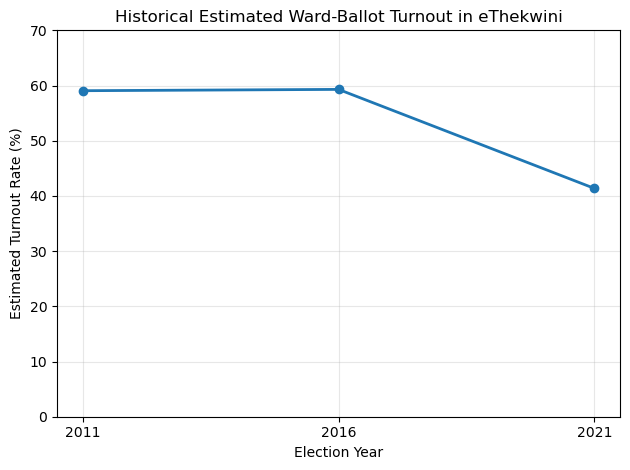

In [84]:
plt.plot(
    metro_turnout_history["ElectionYear"],
    metro_turnout_history["EstimatedTurnoutRate"],
    marker="o",
    linewidth=2
)

plt.title("Historical Estimated Ward-Ballot Turnout in eThekwini")
plt.xlabel("Election Year")
plt.ylabel("Estimated Turnout Rate (%)")

plt.xticks([2011, 2016, 2021])
plt.ylim(0, 70)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Turnout Forecast Assessment

Historical estimated Ward-ballot turnout in eThekwini was approximately
59.06% in 2011, 59.30% in 2016 and 41.36% in 2021.

Several regression models were evaluated to determine whether voting-district
turnout could be reliably forecast for 2026. A time-based validation approach
was used, where 2016 observations were used for training and 2021 observations
were used for testing.

The tested models performed poorly on the unseen 2021 election. The best
R² value was -2.763, while the mean absolute error was approximately
17.4 percentage points.

A negative R² indicates that the model performed worse than a simple
mean-based prediction on the unseen election data. Therefore, the available
historical variables were considered insufficient for producing a defensible
machine-learning turnout forecast for 2026.

For this reason, no precise 2026 turnout percentage or number of voters is
reported as a reliable model prediction. This avoids presenting an unsupported
estimate as an evidence-based forecast. Additional information, such as the
2026 registered-voter roll and other turnout-related variables, would be
required to produce a stronger forecast.

In [85]:
import pickle

with open("ethekwini_2026_party_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

print("Party prediction model saved successfully!")

Party prediction model saved successfully!


In [86]:
model_info = {
    "Municipality": "eThekwini Metropolitan Municipality",
    "ElectionYear": 2026,
    "Model": "Linear Regression",
    "Features": features,
    "Validation_R2": 0.8165,
    "Validation_MAE": 7.2654,
    "Validation_RMSE": 10.9943,
    "TrainingObservations": 5175,
    "TurnoutModelUsed": False,
    "TurnoutReason": (
        "Turnout models failed time-based validation; "
        "best R2 was -2.7630."
    )
}

with open("ethekwini_2026_model_info.pkl", "wb") as file:
    pickle.dump(model_info, file)

# Save prediction tables
metro_2026.to_csv(
    "ethekwini_2026_metro_predictions.csv",
    index=False
)

ward_2026_predictions.to_csv(
    "ethekwini_2026_ward_predictions.csv",
    index=False
)

ward_leaders_2026.to_csv(
    "ethekwini_2026_ward_leaders.csv"
)

print("Model information saved successfully!")
print("Metro predictions saved successfully!")
print("Ward predictions saved successfully!")
print("Ward leaders saved successfully!")

Model information saved successfully!
Metro predictions saved successfully!
Ward predictions saved successfully!
Ward leaders saved successfully!


In [87]:
%%writefile app.py

import streamlit as st
import pandas as pd
import pickle

st.set_page_config(
    page_title="eThekwini 2026 Election Analytics",
    page_icon="📊",
    layout="wide"
)

st.title("eThekwini 2026 Local Government Election Analytics")
st.write(
    "Machine-learning analysis and projections for "
    "eThekwini Metropolitan Municipality."
)

st.info(
    "2026 values displayed in this dashboard are model-generated "
    "projections, not official election results."
)

Writing app.py


In [88]:
%%writefile -a app.py

# Load saved model information
with open("ethekwini_2026_model_info.pkl", "rb") as file:
    model_info = pickle.load(file)

# Load prediction results
metro_predictions = pd.read_csv(
    "ethekwini_2026_metro_predictions.csv"
)

ward_predictions = pd.read_csv(
    "ethekwini_2026_ward_predictions.csv"
)

ward_leaders = pd.read_csv(
    "ethekwini_2026_ward_leaders.csv"
)

st.success("Prediction data loaded successfully.")

Appending to app.py


In [89]:
%%writefile -a app.py

st.divider()

st.header("2026 Metro Party Projection")

st.write(
    "The model estimates the Ward-ballot vote share for four "
    "major parties in eThekwini."
)

# Display projected leading party
leading_party = metro_predictions.iloc[0]

col1, col2 = st.columns(2)

with col1:
    st.metric(
        "Projected Leading Party",
        leading_party["PartyName"]
    )

with col2:
    st.metric(
        "Projected Vote Share",
        f'{leading_party["PredictedVoteShare2026"]:.2f}%'
    )

# Display prediction table
display_metro = metro_predictions.copy()

display_metro["PredictedVoteShare2026"] = (
    display_metro["PredictedVoteShare2026"].round(2)
)

display_metro = display_metro.rename(
    columns={
        "PartyName": "Party",
        "PredictedVoteShare2026": "Projected Vote Share (%)"
    }
)

st.subheader("Projected Party Vote Shares")

st.dataframe(
    display_metro,
    use_container_width=True,
    hide_index=True
)

# Bar chart
chart_data = metro_predictions.set_index(
    "PartyName"
)["PredictedVoteShare2026"]

st.bar_chart(chart_data)

st.caption(
    "These are model-generated Ward-ballot projections. "
    "They are not official 2026 election results and the four "
    "party shares are not normalised to 100%."
)

Appending to app.py


In [90]:
%%writefile -a app.py

st.divider()

st.header("Selected Ward Predictions")

st.write(
    "Select one of the three competitive wards analysed "
    "in the forecasting model."
)

selected_ward = st.selectbox(
    "Choose a ward:",
    sorted(ward_predictions["Ward"].unique())
)

selected_data = ward_predictions[
    ward_predictions["Ward"] == selected_ward
].sort_values(
    "PredictedVoteShare2026",
    ascending=False
)

leader = selected_data.iloc[0]
runner_up = selected_data.iloc[1]

margin = (
    leader["PredictedVoteShare2026"]
    - runner_up["PredictedVoteShare2026"]
)

col1, col2, col3 = st.columns(3)

with col1:
    st.metric(
        "Projected Leader",
        leader["PartyName"]
    )

with col2:
    st.metric(
        "Projected Share",
        f'{leader["PredictedVoteShare2026"]:.2f}%'
    )

with col3:
    st.metric(
        "Lead Margin",
        f"{margin:.2f} percentage points"
    )

# Ward prediction table
ward_display = selected_data[
    ["PartyName", "PredictedVoteShare2026"]
].copy()

ward_display["PredictedVoteShare2026"] = (
    ward_display["PredictedVoteShare2026"].round(2)
)

ward_display = ward_display.rename(
    columns={
        "PartyName": "Party",
        "PredictedVoteShare2026": "Projected Vote Share (%)"
    }
)

st.dataframe(
    ward_display,
    use_container_width=True,
    hide_index=True
)

# Ward chart
ward_chart = selected_data.set_index(
    "PartyName"
)["PredictedVoteShare2026"]

st.bar_chart(ward_chart)

st.warning(
    "Ward projections should be interpreted with caution. "
    "Small differences between the leading parties are not "
    "evidence of a certain election outcome."
)

Appending to app.py


In [91]:
%%writefile -a app.py

st.divider()

st.header("Model Performance")

st.write(
    "Four regression algorithms were evaluated using a "
    "time-based validation approach. The model was trained "
    "on earlier election transitions and evaluated on the "
    "unseen 2021 election."
)

col1, col2, col3 = st.columns(3)

with col1:
    st.metric(
        "R² Score",
        f'{model_info["Validation_R2"]:.4f}'
    )

with col2:
    st.metric(
        "MAE",
        f'{model_info["Validation_MAE"]:.2f} pp'
    )

with col3:
    st.metric(
        "RMSE",
        f'{model_info["Validation_RMSE"]:.2f} pp'
    )

st.write(
    "**Selected model:** Linear Regression"
)

st.caption(
    "R² measures how much variation in vote share is explained "
    "by the model. MAE and RMSE measure prediction error in "
    "percentage points."
)

st.subheader("2026 Turnout Assessment")

st.write(
    "A separate modelling process was tested for voter turnout. "
    "However, the turnout models did not generalise successfully "
    "to the unseen 2021 election."
)

st.error(
    "No reliable 2026 turnout prediction is reported. "
    "The best tested turnout model had an R² of -2.7630 "
    "and an MAE of approximately 17.4 percentage points."
)

st.write(
    "Because a negative R² indicates performance worse than a "
    "simple mean-based prediction, the available historical "
    "variables were considered insufficient for a defensible "
    "2026 turnout forecast."
)


Appending to app.py


In [92]:
%%writefile -a app.py

st.divider()

st.header("Historical Turnout")

turnout_history = pd.DataFrame({
    "Election Year": [2011, 2016, 2021],
    "Estimated Turnout (%)": [59.06, 59.30, 41.36]
})

st.line_chart(
    turnout_history.set_index("Election Year")
)

st.caption(
    "Historical turnout values are derived estimates from "
    "Ward-ballot data and should not be interpreted as official "
    "IEC turnout statistics."
)

st.divider()

st.header("Methodology and Limitations")

st.markdown("""
### Methodology

Historical eThekwini local-government election data from 2011, 2016
and 2021 was used.

The party forecasting model uses previous-election:

- vote share
- party votes
- registered voters

A time-based validation approach was used rather than a random
train-test split. Earlier election transitions were used for training
and the 2021 election was used as unseen test data.

### Important Limitations

The 2026 figures are statistical model projections and are **not
official election results**.

Only four major parties are included in the current forecasting model:
ANC, DA, EFF and IFP. Other parties and independent candidates are
therefore not represented in these projections.

Ward and voting-district geography can change between elections.
Historical comparisons were restricted where possible to geographically
comparable units, but geographic change remains a limitation.

The model predicts Ward-ballot vote share. It does not directly predict
municipal council seats or determine which party or coalition will
govern eThekwini.

A reliable 2026 turnout prediction could not be produced from the
available variables because the tested turnout models failed
time-based validation.
""")

st.divider()

st.caption(
    "eThekwini 2026 Local Government Election Analytics | "
    "Educational forecasting project"
)

Appending to app.py


In [93]:
# Check the years currently paired by the lag features

lag_check = model_data[
    ["ElectionYear", "VotingDistrict", "PartyName"]
].copy()

lag_check["PreviousYear"] = (
    lag_check
    .groupby(["VotingDistrict", "PartyName"])["ElectionYear"]
    .shift(1)
)

lag_check["YearGap"] = (
    lag_check["ElectionYear"] - lag_check["PreviousYear"]
)

print("Year-gap counts:")
print(lag_check["YearGap"].value_counts().sort_index())

print("\nRows where the previous observation is NOT exactly 5 years earlier:")
display(
    lag_check[
        lag_check["PreviousYear"].notna() &
        (lag_check["YearGap"] != 5)
    ].head(20)
)

Year-gap counts:
YearGap
5.0     5112
10.0      63
Name: count, dtype: int64

Rows where the previous observation is NOT exactly 5 years earlier:


,ElectionYear,VotingDistrict,PartyName,PreviousYear,YearGap
7071,2021,43350195,AFRICAN NATIONAL CONGRESS,2011.0,10.0
7072,2021,43350195,DEMOCRATIC ALLIANCE,2011.0,10.0
7074,2021,43350195,INKATHA FREEDOM PARTY,2011.0,10.0
6274,2021,43360310,INKATHA FREEDOM PARTY,2011.0,10.0
6511,2021,43360624,AFRICAN NATIONAL CONGRESS,2011.0,10.0
6512,2021,43360624,DEMOCRATIC ALLIANCE,2011.0,10.0
6514,2021,43360624,INKATHA FREEDOM PARTY,2011.0,10.0
6663,2021,43360848,AFRICAN NATIONAL CONGRESS,2011.0,10.0
6664,2021,43360848,DEMOCRATIC ALLIANCE,2011.0,10.0
6666,2021,43360848,INKATHA FREEDOM PARTY,2011.0,10.0


In [94]:
# =====================================================
# CREATE EXACT 5-YEAR LAG FEATURES
# =====================================================

# Current-election observations
current_data = model_data.copy()

# Previous-election observations
previous_data = model_data[
    [
        "ElectionYear",
        "VotingDistrict",
        "PartyName",
        "PartyVoteShare",
        "PartyVotes",
        "RegisteredVoters"
    ]
].copy()

# Move each historical observation forward by exactly 5 years
previous_data["ElectionYear"] = (
    previous_data["ElectionYear"] + 5
)

# Rename previous-election variables
previous_data = previous_data.rename(
    columns={
        "PartyVoteShare": "PreviousVoteShare",
        "PartyVotes": "PreviousPartyVotes",
        "RegisteredVoters": "PreviousRegisteredVoters"
    }
)

# Exact match:
# same year target + same VD + same party
ml_data_exact = current_data.merge(
    previous_data,
    on=[
        "ElectionYear",
        "VotingDistrict",
        "PartyName"
    ],
    how="inner"
)

print("Exact 5-year training observations:")
print(len(ml_data_exact))

print("\nObservations by target election year:")
print(
    ml_data_exact["ElectionYear"]
    .value_counts()
    .sort_index()
)

print("\nExact-lag columns:")
print(ml_data_exact.columns.tolist())

Exact 5-year training observations:
5112

Observations by target election year:
ElectionYear
2016    2045
2021    3067
Name: count, dtype: int64

Exact-lag columns:
['ElectionYear', 'Ward', 'VotingDistrict', 'PartyName', 'RegisteredVoters', 'PartyVotes', 'VDTotalValidVotes', 'PartyVoteShare', 'PreviousVoteShare_x', 'PreviousPartyVotes_x', 'PreviousRegisteredVoters_x', 'PreviousVoteShare_y', 'PreviousPartyVotes_y', 'PreviousRegisteredVoters_y']


In [95]:
# Keep only the correctly matched exact-lag variables

ml_data_exact = ml_data_exact[
    [
        "ElectionYear",
        "Ward",
        "VotingDistrict",
        "PartyName",
        "RegisteredVoters",
        "PartyVotes",
        "VDTotalValidVotes",
        "PartyVoteShare",
        "PreviousVoteShare_y",
        "PreviousPartyVotes_y",
        "PreviousRegisteredVoters_y"
    ]
].copy()

# Rename the correct exact-lag columns
ml_data_exact = ml_data_exact.rename(
    columns={
        "PreviousVoteShare_y": "PreviousVoteShare",
        "PreviousPartyVotes_y": "PreviousPartyVotes",
        "PreviousRegisteredVoters_y": "PreviousRegisteredVoters"
    }
)

print("Clean corrected dataset shape:", ml_data_exact.shape)

print("\nColumns:")
print(ml_data_exact.columns.tolist())

print("\nTarget years:")
print(ml_data_exact["ElectionYear"].value_counts().sort_index())

Clean corrected dataset shape: (5112, 11)

Columns:
['ElectionYear', 'Ward', 'VotingDistrict', 'PartyName', 'RegisteredVoters', 'PartyVotes', 'VDTotalValidVotes', 'PartyVoteShare', 'PreviousVoteShare', 'PreviousPartyVotes', 'PreviousRegisteredVoters']

Target years:
ElectionYear
2016    2045
2021    3067
Name: count, dtype: int64


In [96]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Features and target
features = [
    "PreviousVoteShare",
    "PreviousPartyVotes",
    "PreviousRegisteredVoters"
]

target = "PartyVoteShare"

# Time-based split
train_exact = ml_data_exact[
    ml_data_exact["ElectionYear"] == 2016
].copy()

test_exact = ml_data_exact[
    ml_data_exact["ElectionYear"] == 2021
].copy()

X_train_exact = train_exact[features]
y_train_exact = train_exact[target]

X_test_exact = test_exact[features]
y_test_exact = test_exact[target]

# Models
models_exact = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

results_exact = []

# Train and evaluate
for name, model in models_exact.items():

    model.fit(X_train_exact, y_train_exact)

    predictions = model.predict(X_test_exact)

    mae = mean_absolute_error(
        y_test_exact,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_exact,
            predictions
        )
    )

    r2 = r2_score(
        y_test_exact,
        predictions
    )

    results_exact.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_exact_df = pd.DataFrame(
    results_exact
).sort_values("R2", ascending=False)

print("CORRECTED MODEL COMPARISON")
display(results_exact_df.round(4))

CORRECTED MODEL COMPARISON


,Model,MAE,RMSE,R2
0,Linear Regression,7.3056,11.0389,0.8162
3,Gradient Boosting,7.8125,12.0511,0.7810
2,Random Forest,8.0765,12.6039,0.7605
1,Decision Tree,9.7295,15.4280,0.6411


In [97]:
# =====================================================
# TRAIN FINAL CORRECTED LINEAR REGRESSION MODEL
# =====================================================

X_all_exact = ml_data_exact[features]
y_all_exact = ml_data_exact[target]

final_model_exact = LinearRegression()

final_model_exact.fit(
    X_all_exact,
    y_all_exact
)

print("Final corrected Linear Regression model trained successfully!")
print("Training observations:", len(X_all_exact))
print("Features used:", features)

print("\nCorrected validation performance:")
print("R²: 0.8162")
print("MAE: 7.3056")
print("RMSE: 11.0389")

Final corrected Linear Regression model trained successfully!
Training observations: 5112
Features used: ['PreviousVoteShare', 'PreviousPartyVotes', 'PreviousRegisteredVoters']

Corrected validation performance:
R²: 0.8162
MAE: 7.3056
RMSE: 11.0389


In [98]:
# PREPARE 2026 INPUT FOR CORRECTED MODEL
# =====================================================

prediction_2026_exact = model_data[
    model_data["ElectionYear"] == 2021
].copy()

# 2021 becomes the previous-election information
# used to predict 2026
prediction_2026_exact["PreviousVoteShare"] = (
    prediction_2026_exact["PartyVoteShare"]
)

prediction_2026_exact["PreviousPartyVotes"] = (
    prediction_2026_exact["PartyVotes"]
)

prediction_2026_exact["PreviousRegisteredVoters"] = (
    prediction_2026_exact["RegisteredVoters"]
)

# Generate corrected 2026 predictions
prediction_2026_exact["PredictedVoteShare2026"] = (
    final_model_exact.predict(
        prediction_2026_exact[features]
    )
)

print("2026 prediction observations:")
print(len(prediction_2026_exact))

print("\nCorrected 2026 prediction summary:")
print(
    prediction_2026_exact[
        "PredictedVoteShare2026"
    ].describe()
)

print("\nPredictions below 0%:")
print(
    (
        prediction_2026_exact["PredictedVoteShare2026"] < 0
    ).sum()
)

print("\nPredictions above 100%:")
print(
    (
        prediction_2026_exact["PredictedVoteShare2026"] > 100
    ).sum()
)

2026 prediction observations:
3200

Corrected 2026 prediction summary:
count    3200.000000
mean       21.200427
std        21.075455
min         3.840521
25%         5.664541
50%        10.438528
75%        31.883476
max        84.201416
Name: PredictedVoteShare2026, dtype: float64

Predictions below 0%:
0

Predictions above 100%:
0


In [102]:
print(
    prediction_2026_exact["PartyName"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

['AFRICAN NATIONAL CONGRESS', 'DEMOCRATIC ALLIANCE', 'ECONOMIC FREEDOM FIGHTERS', 'INKATHA FREEDOM PARTY']


In [103]:
print("Ward data type:")
print(prediction_2026_exact["Ward"].dtype)

print("\nExample Ward values:")
print(
    prediction_2026_exact["Ward"]
    .drop_duplicates()
    .head(10)
    .tolist()
)

Ward data type:
str

Example Ward values:
['Ward 59500035', 'Ward 59500102', 'Ward 59500058', 'Ward 59500059', 'Ward 59500062', 'Ward 59500060', 'Ward 59500061', 'Ward 59500026', 'Ward 59500053', 'Ward 59500028']


In [104]:
# =====================================================
# CORRECTED 2026 SELECTED-WARD PROJECTIONS
# =====================================================

selected_wards = [
    "Ward 59500009",
    "Ward 59500026",
    "Ward 59500099"
]

major_parties = [
    "AFRICAN NATIONAL CONGRESS",
    "DEMOCRATIC ALLIANCE",
    "ECONOMIC FREEDOM FIGHTERS",
    "INKATHA FREEDOM PARTY"
]

ward_2026_exact = prediction_2026_exact[
    prediction_2026_exact["Ward"].isin(selected_wards)
    & prediction_2026_exact["PartyName"].isin(major_parties)
].copy()

# Weight each voting-district prediction
# using its 2021 valid-vote volume
ward_2026_exact["WeightedPrediction"] = (
    ward_2026_exact["PredictedVoteShare2026"]
    * ward_2026_exact["VDTotalValidVotes"]
)

ward_predictions_exact = (
    ward_2026_exact
    .groupby(["Ward", "PartyName"])
    .agg(
        WeightedPrediction=("WeightedPrediction", "sum"),
        TotalWeight=("VDTotalValidVotes", "sum")
    )
    .reset_index()
)

ward_predictions_exact["PredictedVoteShare2026"] = (
    ward_predictions_exact["WeightedPrediction"]
    / ward_predictions_exact["TotalWeight"]
)

ward_predictions_exact = (
    ward_predictions_exact[
        ["Ward", "PartyName", "PredictedVoteShare2026"]
    ]
    .sort_values(
        ["Ward", "PredictedVoteShare2026"],
        ascending=[True, False]
    )
)

display(ward_predictions_exact.round(2))

,Ward,PartyName,PredictedVoteShare2026
1,Ward 59500009,DEMOCRATIC ALLIANCE,33.53
0,Ward 59500009,AFRICAN NATIONAL CONGRESS,32.21
2,Ward 59500009,ECONOMIC FREEDOM FIGHTERS,6.73
3,Ward 59500009,INKATHA FREEDOM PARTY,5.32
4,Ward 59500026,AFRICAN NATIONAL CONGRESS,30.31
5,Ward 59500026,DEMOCRATIC ALLIANCE,29.99
6,Ward 59500026,ECONOMIC FREEDOM FIGHTERS,13.89
7,Ward 59500026,INKATHA FREEDOM PARTY,7.57
8,Ward 59500099,AFRICAN NATIONAL CONGRESS,29.36
11,Ward 59500099,INKATHA FREEDOM PARTY,25.65


In [105]:
# =====================================================
# CORRECTED 2026 METRO PROJECTION
# =====================================================

metro_2026_exact = prediction_2026_exact[
    prediction_2026_exact["PartyName"].isin(major_parties)
].copy()

# Weight each VD prediction by its 2021 valid-vote volume
metro_2026_exact["WeightedPrediction"] = (
    metro_2026_exact["PredictedVoteShare2026"]
    * metro_2026_exact["VDTotalValidVotes"]
)

metro_predictions_exact = (
    metro_2026_exact
    .groupby("PartyName")
    .agg(
        WeightedPrediction=("WeightedPrediction", "sum"),
        TotalWeight=("VDTotalValidVotes", "sum")
    )
    .reset_index()
)

metro_predictions_exact["PredictedVoteShare2026"] = (
    metro_predictions_exact["WeightedPrediction"]
    / metro_predictions_exact["TotalWeight"]
)

metro_predictions_exact = (
    metro_predictions_exact[
        ["PartyName", "PredictedVoteShare2026"]
    ]
    .sort_values(
        "PredictedVoteShare2026",
        ascending=False
    )
)

display(metro_predictions_exact.round(2))

,PartyName,PredictedVoteShare2026
0,AFRICAN NATIONAL CONGRESS,37.78
1,DEMOCRATIC ALLIANCE,25.53
2,ECONOMIC FREEDOM FIGHTERS,12.24
3,INKATHA FREEDOM PARTY,9.37


In [106]:
# =====================================================
# SAVE FINAL CORRECTED MODEL AND PREDICTION FILES
# =====================================================

import pickle

# 1. Save corrected final model
with open("ethekwini_2026_party_model.pkl", "wb") as file:
    pickle.dump(final_model_exact, file)


# 2. Create corrected model information
model_info_exact = {
    "Municipality": "eThekwini Metropolitan Municipality",
    "ElectionYear": 2026,
    "Model": "Linear Regression",
    "Features": features,
    "Validation_R2": 0.8162,
    "Validation_MAE": 7.3056,
    "Validation_RMSE": 11.0389,
    "TrainingObservations": 5112,
    "TurnoutModelUsed": False,
    "TurnoutReason":
        "Turnout models failed time-based validation; "
        "best R2 was approximately -2.7630."
}

with open("ethekwini_2026_model_info.pkl", "wb") as file:
    pickle.dump(model_info_exact, file)


# 3. Save corrected metro predictions
metro_predictions_exact.to_csv(
    "ethekwini_2026_metro_predictions.csv",
    index=False
)


# 4. Save corrected ward predictions
ward_predictions_exact.to_csv(
    "ethekwini_2026_ward_predictions.csv",
    index=False
)


# 5. Create corrected ward-leader table
ward_leaders_exact = (
    ward_predictions_exact
    .sort_values(
        ["Ward", "PredictedVoteShare2026"],
        ascending=[True, False]
    )
    .groupby("Ward")
    .head(1)
    .reset_index(drop=True)
)

ward_leaders_exact.to_csv(
    "ethekwini_2026_ward_leaders.csv",
    index=False
)


print("FINAL CORRECTED FILES SAVED SUCCESSFULLY")
print()
print("Model observations: 5112")
print("Validation R²: 0.8162")
print("Validation MAE: 7.3056")
print("Validation RMSE: 11.0389")

print("\nSaved files:")
print("- ethekwini_2026_party_model.pkl")
print("- ethekwini_2026_model_info.pkl")
print("- ethekwini_2026_metro_predictions.csv")
print("- ethekwini_2026_ward_predictions.csv")
print("- ethekwini_2026_ward_leaders.csv")

FINAL CORRECTED FILES SAVED SUCCESSFULLY

Model observations: 5112
Validation R²: 0.8162
Validation MAE: 7.3056
Validation RMSE: 11.0389

Saved files:
- ethekwini_2026_party_model.pkl
- ethekwini_2026_model_info.pkl
- ethekwini_2026_metro_predictions.csv
- ethekwini_2026_ward_predictions.csv
- ethekwini_2026_ward_leaders.csv
